# Comprehensive Performance Evaluation and Analysis

In [ ]:
!pip install transformers seqeval evaluate accelerate -U
!pip install transformers seqeval evaluate accelerate pytorch-crf -U

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.6/43.6 kB 3.7 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 7.4 MB/s eta 0:00:00
  Created wheel for seqeval: filename=seqeval-1.2.2-py3-none-any.whl size=16162 sha256=00bdecbd93e27ff34a342a3770be7f525433fb8c1d6de09b8b3f304639eccd14
  Stored in directory: /root/.cache/pip/wheels/14/cf/a7/8f28ef376d707ff10e3922899482a2f23ef3002f8a952f47ac
Successfully built seqeval


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
label_path = '/content/drive/MyDrive/datasetViMedNER/traindata/labels.txt'

unique_tags = []
with open(label_path, "r", encoding = "utf-8") as f :
    for line in f:
        line.strip()
        if line.strip():
          unique_tags.append(line.strip())

label2id = {tag: idx for idx, tag in enumerate(unique_tags)}
id2label = {idx: tag for idx, tag in enumerate(unique_tags)}

In [ ]:
import torch
import torch.nn as nn
from transformers import AutoModel
from transformers.modeling_outputs import TokenClassifierOutput
from torchcrf import CRF

class PhoBERT_CRF(nn.Module):
    def __init__(self, model_checkpoint, num_labels):
        super().__init__()
        self.phobert = AutoModel.from_pretrained(model_checkpoint, add_pooling_layer = False)
        self.classifier = nn.Linear(self.phobert.config.hidden_size, num_labels)
        self.crf = CRF(num_labels, batch_first = True)

    def forward(self, input_ids, attention_mask, labels = None, **kwargs):
        outputs = self.phobert(input_ids = input_ids, attention_mask = attention_mask) # đưa qua phobert lấy ngữ cảnh câu

        sequence_output = outputs.last_hidden_state

        emissions = self.classifier(sequence_output) # đưa ra kết quả thô của từng nhãn

        loss = None
        if labels is not None:
            crf_mask = attention_mask.bool() # chuyển nhãn không hợp lệ thành True False để xác định những vị trí cần tính crf

            # đổi quy ước của labels khi đưa qua crf
            safe_labels = labels.clone()
            safe_labels[safe_labels == -100] = 0 #các labels padding, sub_token chuyển nhãn 0

            loss = -self.crf(emissions, safe_labels, mask = crf_mask, reduction = 'mean')

        # tạo một ma trận kết quả phụ để mô hình có thể sử dụng kết quả
        crf_mask_decode = attention_mask.bool()
        decoded_paths = self.crf.decode(emissions, mask = crf_mask_decode)

        fake_logits = torch.zeros_like(emissions)
        for i, path in enumerate(decoded_paths):
            for j, tag_id in enumerate(path):
                fake_logits[i, j, tag_id] = 1.0

        return TokenClassifierOutput(loss=loss, logits=fake_logits)

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from transformers import AutoModel
from transformers.modeling_outputs import TokenClassifierOutput

class FocalLoss(nn.Module):
    def __init__(self, gamma=2.0, alpha = None):
        super().__init__()
        self.gamma = gamma
        self.alpha = alpha
    def forward(self, logits, targets, mask):
        logits = logits.view(-1, logits.size(-1))
        targets = targets.view(-1)
        mask = mask.view(-1)

        logits = logits[mask]
        targets = targets[mask]

        ce_loss = F.cross_entropy(logits, targets, reduction='none')
        pt = torch.exp(-ce_loss)
        focal_loss = ((1 - pt) ** self.gamma) * ce_loss
        return focal_loss.mean()

class PhoBERT_Focal(nn.Module):
    def __init__(self, model_checkpoint, num_labels):
        super().__init__()
        self.num_labels = num_labels

        self.phobert = AutoModel.from_pretrained(model_checkpoint, add_pooling_layer=False)
        self.classifier = nn.Linear(self.phobert.config.hidden_size, num_labels)

        # Chỉ dùng Focal Loss, không có CRF
        self.focal_loss = FocalLoss(gamma=2.0)

    def forward(self, input_ids, attention_mask, labels=None, **kwargs):
        outputs = self.phobert(input_ids=input_ids, attention_mask=attention_mask)
        sequence_output = outputs.last_hidden_state

        # Điểm số dự đoán thô
        logits = self.classifier(sequence_output)

        loss = None
        if labels is not None:
            # Mask bỏ qua các token -100
            loss_mask = (labels != -100)

            # Tính Focal Loss trực tiếp trên logits thay vì Cross Entropy
            loss = self.focal_loss(logits, labels, loss_mask)

        return TokenClassifierOutput(loss=loss, logits=logits)

In [ ]:
class PhoBERT_Focal_CRF(nn.Module):
    def __init__(self, model_checkpoint, num_labels, gamma=2.0, alpha=None):
        super().__init__()
        self.num_labels = num_labels
        self.phobert = AutoModel.from_pretrained(model_checkpoint, add_pooling_layer=False)
        self.classifier = nn.Linear(self.phobert.config.hidden_size, num_labels)

        # 1. Khởi tạo CRF layer
        self.crf = CRF(num_labels, batch_first=True)

        # 2. Khởi tạo Focal Loss
        self.focal_loss = FocalLoss(gamma=gamma, alpha=alpha)

    def forward(self, input_ids, attention_mask, labels=None, **kwargs):
        outputs = self.phobert(input_ids=input_ids, attention_mask=attention_mask)

        # Truyền thẳng đầu ra (không qua Dropout) vào bộ phân loại
        sequence_output = outputs.last_hidden_state
        logits = self.classifier(sequence_output)

        loss = None
        if labels is not None:
            # A. TÍNH CRF LOSS (Sequence-level)
            crf_mask = attention_mask.bool()
            safe_labels = labels.clone()
            safe_labels[safe_labels == -100] = 0 # Gán tạm nhãn 0 cho padding/sub_token
            crf_loss = -self.crf(logits, safe_labels, mask=crf_mask, reduction='mean')

            # B. TÍNH FOCAL LOSS (Token-level)
            focal_mask = (labels != -100) # Chỉ tính loss trên các token thật
            focal_loss_val = self.focal_loss(logits, labels, focal_mask)

            # C. TỔNG HỢP LOSS
            loss = crf_loss + focal_loss_val
        # D. GIẢI MÃ (DECODE) BẰNG CRF ĐỂ ĐÁNH GIÁ
        crf_mask_decode = attention_mask.bool()
        decoded_paths = self.crf.decode(logits, mask=crf_mask_decode)

        # Tạo fake_logits để tương thích hoàn toàn với hàm compute_metrics
        fake_logits = torch.zeros_like(logits)
        for i, path in enumerate(decoded_paths):
            for j, tag_id in enumerate(path):
                fake_logits[i, j, tag_id] = 1.0

        return TokenClassifierOutput(loss=loss, logits=fake_logits)

In [ ]:
label_path = '/content/drive/MyDrive/datasetViMedNER/traindata/labels.txt'
train_path = '/content/drive/MyDrive/datasetViMedNER/traindata/train.txt'
dev_path = '/content/drive/MyDrive/datasetViMedNER/traindata/dev.txt'

unique_tags = []
with open(label_path, "r", encoding = "utf-8") as f :
    for line in f:
        line.strip()
        if line.strip():
          unique_tags.append(line.strip())

label2id = {tag: idx for idx, tag in enumerate(unique_tags)}
id2label = {idx: tag for idx, tag in enumerate(unique_tags)}

def load_conll_data(file_path):
    sentences = []
    current_sentence = []

    with open(file_path, 'r', encoding='utf-8') as f:
        for line in f:
            line = line.strip()
            if not line:
                if current_sentence:
                    sentences.append(current_sentence)
                    current_sentence = []
            else:
                parts = line.split()
                if len(parts) >= 2:
                    word, tag = parts[0], parts[1]
                    current_sentence.append((word, tag))
        if current_sentence:
            sentences.append(current_sentence)
    return sentences

train_sentences = load_conll_data(train_path)
dev_sentences = load_conll_data(dev_path)

In [ ]:
sentence_lengths = []
entity_lengths = []
all_tags = set()
tag_counts = {}

for sent in train_sentences:
    sentence_lengths.append(len(sent))

    # Trích xuất thực thể từ chuỗi B- / I-
    in_entity = False
    current_ent_len = 0

    for word, tag in sent:
        all_tags.add(tag)
        tag_counts[tag] = tag_counts.get(tag, 0) + 1

        if tag.startswith('B-'):
            if in_entity:
                entity_lengths.append(current_ent_len)
            in_entity = True
            current_ent_len = 1
        elif tag.startswith('I-') and in_entity:
            current_ent_len += 1
        else:
            if in_entity:
                entity_lengths.append(current_ent_len)
                in_entity = False
                current_ent_len = 0
    if in_entity:
        entity_lengths.append(current_ent_len)

In [ ]:
import math
import torch
import numpy as np

# Giả định Thành đã chạy sẵn tag_counts và label2id ở trên
sum_tag = sum(tag_counts.values())

# 1. Tính toán w_freq (Tần suất) và w_diff (Độ khó)
w_freq = np.zeros(len(label2id))
for tag, idx in label2id.items():
    w_freq[idx] = math.sqrt(sum_tag / tag_counts[tag])

f1_scores = {
    0: 0.7331, 1: 0.7152, 2: 0.2143, 3: 0.8694, 4: 0.6938,
    5: 0.6971, 6: 0.6108, 7: 0.1908, 8: 0.8946, 9: 0.6224,
    10: 0.9437 # Nhãn O
}

# Lấy điểm F1 cao nhất của nhóm thực thể (loại nhãn O)
f1_max = max(list(f1_scores.values())[:-1])

w_diff = np.zeros(len(label2id))
for tag, idx in label2id.items():
    w_diff[idx] = math.sqrt(f1_max / f1_scores[idx])

# 2. Tính static weight thô
static_weight_raw = w_freq * w_diff

# 3. Tinh chỉnh Scale (Chỉ xét min/max trên nhóm thực thể)
O_index = label2id['O']
entity_weights = np.delete(static_weight_raw, O_index)

min_w = np.min(entity_weights)
max_w = np.max(entity_weights)

target_min = 0.5
target_max = 3.0

static_weight_scaled = np.zeros_like(static_weight_raw)

for idx in range(len(static_weight_raw)):
    if idx == O_index:
        continue
    # Công thức Min-Max chuẩn: giữ nguyên tỷ lệ thuận (khó -> to, dễ -> nhỏ)
    static_weight_scaled[idx] = target_min + (static_weight_raw[idx] - min_w) * (target_max - target_min) / (max_w - min_w)

# 4. Ép cứng nhãn O xuống đáy (0.1)
static_weight_scaled[O_index] = 0.1

print("\n--- BẢNG TRỌNG SỐ SAU KHI SCALE CHUẨN ---")
for tag, idx in label2id.items():
    print(f"{idx:2d} | {tag:25s} | Weight = {static_weight_scaled[idx]:.4f}")

# 5. Chuyển thành PyTorch Tensor sẵn sàng dùng cho model
static_weight_tensor = torch.tensor(static_weight_scaled, dtype=torch.float)


--- BẢNG TRỌNG SỐ SAU KHI SCALE CHUẨN ---
 0 | B-bien_phap_chan_doan     | Weight = 1.6764
 1 | B-bien_phap_dieu_tri      | Weight = 1.2559
 2 | B-nguyen_nhan_benh        | Weight = 3.0000
 3 | B-ten_benh                | Weight = 0.7113
 4 | B-trieu_chung_benh        | Weight = 1.1118
 5 | I-bien_phap_chan_doan     | Weight = 1.0674
 6 | I-bien_phap_dieu_tri      | Weight = 0.8675
 7 | I-nguyen_nhan_benh        | Weight = 1.6380
 8 | I-ten_benh                | Weight = 0.5000
 9 | I-trieu_chung_benh        | Weight = 0.8562
10 | O                         | Weight = 0.1000


In [ ]:
import math
import torch
import torch.nn as nn
import torch.nn.functional as F
from transformers import AutoModel
from transformers.modeling_outputs import TokenClassifierOutput
from torchcrf import CRF

class EntityAware_ViMedNER(nn.Module):
    def __init__(self, model_checkpoint, num_labels, static_weights, lambda_weight= 1.0, gamma_len=1.0):
        super().__init__()
        self.num_labels = num_labels
        self.lambda_weight = lambda_weight
        self.gamma_len = gamma_len
        self.phobert = AutoModel.from_pretrained(model_checkpoint, add_pooling_layer=False)
        self.classifier = nn.Linear(self.phobert.config.hidden_size, num_labels)
        self.crf = CRF(num_labels, batch_first=True)
        self.register_buffer('w_class', torch.tensor(static_weights, dtype=torch.float))

        # Thêm biến đếm để in log Loss
        self.batch_counter = 0

    def _get_span_weight_mask(self, labels):
        batch_size, seq_len = labels.shape
        mask = torch.ones((batch_size, seq_len), device=labels.device)

        O_LABEL_ID = 10
        # Khai báo danh sách các nhãn B- (dựa trên label2id)
        B_LABEL_IDS = [0, 1, 2, 3, 4]

        for i in range(batch_size):
            seq_labels = labels[i].tolist()
            start = -1
            for j in range(seq_len):
                lbl = seq_labels[j]

                # LOGIC MỚI: Cắt cụm nếu gặp O, PAD hoặc bắt đầu một nhãn B- mới
                if lbl == -100 or lbl == O_LABEL_ID or lbl in B_LABEL_IDS:
                    if start != -1:
                        # Kết thúc cụm cũ, tính w_len và gán
                        span_len = j - start
                        w_len = 1.0 + self.gamma_len * math.log(1.0 + span_len)
                        mask[i, start:j] = w_len
                        start = -1

                # Khởi tạo cụm mới nếu token là thực thể (B- hoặc I-)
                if lbl != -100 and lbl != O_LABEL_ID:
                    if start == -1:
                        start = j

            # Chốt sổ đoạn cuối câu
            if start != -1:
                span_len = seq_len - start
                w_len = 1.0 + self.gamma_len * math.log(1.0 + span_len)
                mask[i, start:seq_len] = w_len
        return mask

    def forward(self, input_ids, attention_mask, labels=None, **kwargs):
        outputs = self.phobert(input_ids=input_ids, attention_mask=attention_mask)
        sequence_output = outputs.last_hidden_state
        emissions = self.classifier(sequence_output)

        crf_mask = attention_mask.bool()
        crf_mask[:, 0] = True
        loss = None

        if labels is not None:
            # 1. TÍNH MAIN LOSS: CRF
            safe_labels = labels.clone()
            safe_labels[safe_labels == -100] = 10
            l_crf = -self.crf(emissions, safe_labels, mask=crf_mask, reduction='mean')

            # 2. TÍNH AUXILIARY LOSS: Entity-Aware
            l_aux_raw = F.cross_entropy(
                emissions.view(-1, self.num_labels),
                labels.view(-1),
                weight=self.w_class,
                ignore_index=-100,
                reduction='none'
            )

            w_len_mask = self._get_span_weight_mask(labels).view(-1)
            valid_tokens_mask = (labels != -100).view(-1)
            l_aux_weighted = (l_aux_raw * w_len_mask).sum() / (valid_tokens_mask.sum() + 1e-9)

            # 3. TỔNG LOSS
            loss = l_crf + (self.lambda_weight * l_aux_weighted)

        crf_mask_decode = attention_mask.bool()
        decoded_paths = self.crf.decode(emissions, mask=crf_mask_decode)
        fake_logits = torch.zeros_like(emissions)
        for i, path in enumerate(decoded_paths):
            for j, tag_id in enumerate(path):
                fake_logits[i, j, tag_id] = 1.0

        return TokenClassifierOutput(loss=loss, logits=fake_logits)

In [ ]:
import torch
from torch.utils.data import Dataset
from transformers import AutoTokenizer

class ViMedNERDataset(Dataset):
    def __init__(self, sentences, tokenizer, label2id, max_length=128):
        self.sentences = sentences
        self.tokenizer = tokenizer
        self.label2id = label2id
        self.max_length = max_length

    def __len__(self):
        return len(self.sentences)

    def __getitem__(self, idx):
        sentence_data = self.sentences[idx]
        words = [item[0] for item in sentence_data]
        tags = [item[1] for item in sentence_data]

        # Tokenize từng từ và theo dõi số lượng sub-token của mỗi từ
        tokenized_outputs = []
        label_ids = []

        # Thêm token [CLS] đầu câu
        tokenized_outputs.append(self.tokenizer.cls_token_id)
        label_ids.append(-100)

        for word, tag in zip(words, tags):
            # Tokenize từng từ lẻ (không dùng is_split_into_words để tránh lỗi word_ids)
            sub_tokens = self.tokenizer.tokenize(word)
            sub_token_ids = self.tokenizer.convert_tokens_to_ids(sub_tokens)

            if len(sub_token_ids) > 0:
                # Sub-token đầu tiên nhận nhãn thật
                tokenized_outputs.append(sub_token_ids[0])
                label_ids.append(self.label2id[tag])

                # Các sub-token phía sau của cùng 1 từ nhận -100
                for sub_id in sub_token_ids[1:]:
                    tokenized_outputs.append(sub_id)
                    label_ids.append(-100)

        # Thêm token [SEP] cuối câu
        tokenized_outputs.append(self.tokenizer.sep_token_id)
        label_ids.append(-100)

        # Cắt ngắn (Truncation) nếu vượt quá max_length
        if len(tokenized_outputs) > self.max_length:
            tokenized_outputs = tokenized_outputs[:self.max_length]
            label_ids = label_ids[:self.max_length]

        # Tạo attention mask (1 cho token thật, 0 cho padding)
        attention_mask = [1] * len(tokenized_outputs)

        # Padding (Đệm) cho đủ max_length
        padding_length = self.max_length - len(tokenized_outputs)
        if padding_length > 0:
            tokenized_outputs = tokenized_outputs + [self.tokenizer.pad_token_id] * padding_length
            label_ids = label_ids + [-100] * padding_length
            attention_mask = attention_mask + [0] * padding_length

        item = {
            "input_ids": torch.tensor(tokenized_outputs, dtype=torch.long),
            "attention_mask": torch.tensor(attention_mask, dtype=torch.long),
            "labels": torch.tensor(label_ids, dtype=torch.long)
        }
        return item

# 1. Khởi tạo Tokenizer
tokenizer = AutoTokenizer.from_pretrained("vinai/phobert-base-v2")

config.json:   0%|          | 0.00/678 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/895k [00:00<?, ?B/s]

bpe.codes:   0%|          | 0.00/1.14M [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/3.13M [00:00<?, ?B/s]

In [ ]:
import numpy as np
import pandas as pd
import evaluate
from sklearn.metrics import classification_report as sklearn_report
from IPython.display import display

seqeval = evaluate.load("seqeval") # Khai báo seqeval ở đây
def compute_metrics(p):
    predictions, labels = p

    # Biến ma trận xác suất (logits) thành con số ID nhãn dự đoán cao nhất
    predictions = np.argmax(predictions, axis=2)

    # Lọc bỏ các nhãn -100 ra khỏi quá trình tính toán metric
    true_predictions = [
        [id2label[p] for (p, l) in zip(prediction, label) if l != -100]
        for prediction, label in zip(predictions, labels)
    ]
    true_labels = [
        [id2label[l] for (p, l) in zip(prediction, label) if l != -100]
        for prediction, label in zip(predictions, labels)
    ]

    results = seqeval.compute(predictions=true_predictions, references=true_labels)
    return {
        "precision": results["overall_precision"],
        "recall": results["overall_recall"],
        "f1": results["overall_f1"],
        "accuracy": results["overall_accuracy"],
    }

def compute_eval_classify_metrics(pred):
    predictions, labels = pred
    predictions = np.argmax(predictions, axis=2)

    # 1. Lọc nhãn -100 và giữ nguyên cấu trúc List of Lists (dành cho Seqeval)
    true_predictions_seq = [
        [id2label[p] for (p, l) in zip(prediction, label) if l != -100]
        for prediction, label in zip(predictions, labels)
    ]
    true_labels_seq = [
        [id2label[l] for (p, l) in zip(prediction, label) if l != -100]
        for prediction, label in zip(predictions, labels)
    ]

    # 2. Trải phẳng thành mảng 1 chiều (dành cho Sklearn)
    true_predictions_flat = [tag for sent in true_predictions_seq for tag in sent]
    true_labels_flat = [tag for sent in true_labels_seq for tag in sent]

    metrics_dict = {}

    # =========================================================
    # BẢNG 1: ĐÁNH GIÁ THEO CỤM THỰC THỂ HOÀN CHỈNH (SEQEVAL)
    # =========================================================
    results_seq = seqeval.compute(predictions=true_predictions_seq, references=true_labels_seq)
    table_entity = []

    for key, value in results_seq.items():
        if isinstance(value, dict):
            table_entity.append({
                "Thực thể (Entity)": key,
                "Precision": f"{value['precision']:.4f}",
                "Recall": f"{value['recall']:.4f}",
                "F1-Score": f"{value['f1']:.4f}",
                "Number (Entities)": value['number']
            })
            metrics_dict[f"entity_{key}_f1"] = value["f1"]

    table_entity.append({
        "Thực thể (Entity)": "OVERALL",
        "Precision": f"{results_seq['overall_precision']:.4f}",
        "Recall": f"{results_seq['overall_recall']:.4f}",
        "F1-Score": f"{results_seq['overall_f1']:.4f}",
        "Number (Entities)": "-"
    })
    metrics_dict["overall_f1"] = results_seq['overall_f1']

    print("\n" + "="*75)
    print("📊 BẢNG 1: ĐÁNH GIÁ THEO CỤM THỰC THỂ (STRICT ENTITY LEVEL)")
    print("="*75)
    display(pd.DataFrame(table_entity))

    # =========================================================
    # BẢNG 2: ĐÁNH GIÁ CHI TIẾT TỪNG NHÃN RỜI RẠC (SKLEARN)
    # =========================================================
    report_tag = sklearn_report(true_labels_flat, true_predictions_flat, output_dict=True, zero_division=0)
    table_tag = []

    for key, value in report_tag.items():
        if key in ["accuracy", "macro avg", "weighted avg"]:
            continue
        table_tag.append({
            "Nhãn (Tag)": key,
            "Precision": f"{value['precision']:.4f}",
            "Recall": f"{value['recall']:.4f}",
            "F1-Score": f"{value['f1-score']:.4f}",
            "Number (Tokens)": int(value['support'])
        })

    overall_tag = report_tag["weighted avg"]
    table_tag.append({
        "Nhãn (Tag)": "OVERALL (Weighted)",
        "Precision": f"{overall_tag['precision']:.4f}",
        "Recall": f"{overall_tag['recall']:.4f}",
        "F1-Score": f"{overall_tag['f1-score']:.4f}",
        "Number (Tokens)": int(overall_tag['support'])
    })

    print("\n" + "="*75)
    print("📊 BẢNG 2: ĐÁNH GIÁ CHI TIẾT TỪNG NHÃN (TOKEN TAG LEVEL: B-, I-, O)")
    print("="*75)
    display(pd.DataFrame(table_tag))

    return metrics_dict

In [ ]:
import pickle
def load_dataset(file_path):
    with open(file_path,'rb') as f :
        dataset = pickle.load(f)
    return dataset

test_dataset_filepath = '/content/drive/MyDrive/datasetViMedNER/PreprocessedData/test_dataset.pkl'
test_dataset = load_dataset(test_dataset_filepath)

In [ ]:
import os
import torch
import pandas as pd
import safetensors.torch
from transformers import Trainer, TrainingArguments
from transformers import AutoModelForTokenClassification, DataCollatorForTokenClassification, AutoTokenizer
from IPython.display import display

data_collator = DataCollatorForTokenClassification(tokenizer)

# 1. Khởi tạo danh sách lưu kết quả
results_table = []

# Cấu hình Trainer cơ bản chỉ dùng để đánh giá (Inference)
eval_args = TrainingArguments(
    output_dir="./eval_temp",
    per_device_eval_batch_size=16,
    report_to="none"
)

# 2. Hàm helper tự động nạp trọng số và lấy điểm
def trainer_model(model_name, model_instance, checkpoint_path, dataset):
    print(f"⏳ Đang tải và đánh giá: {model_name}...")

    bin_path = os.path.join(checkpoint_path, "pytorch_model.bin")
    safetensor_path = os.path.join(checkpoint_path, "model.safetensors")

    # 1. Ưu tiên tuyệt đối nạp file pytorch_model.bin cho các mô hình Custom
    if os.path.exists(bin_path):
        state_dict = torch.load(bin_path, map_location="cpu")
        model_instance.load_state_dict(state_dict, strict=False)
        print(f"✅ Đã nạp thành công trọng số từ: pytorch_model.bin")

    # 2. Nếu không có file bin (ví dụ Baseline), mới dùng safetensors
    elif os.path.exists(safetensor_path):
        import safetensors.torch
        safetensors.torch.load_model(model_instance, safetensor_path)
        print(f"✅ Đã nạp thành công trọng số từ: model.safetensors")

    else:
        print(f"⚠️ Cảnh báo: Không tìm thấy file trọng số tại {checkpoint_path}")
        return None

    model_instance.eval()

    # Tạo Trainer để chạy dự đoán
    eval_trainer = Trainer(
        model=model_instance,
        args=eval_args,
        eval_dataset=dataset,
        data_collator=data_collator,
        compute_metrics=compute_metrics
    )
    return eval_trainer

In [ ]:
num_labels = len(label2id)
# baseline_trainer
model_baseline = AutoModelForTokenClassification.from_pretrained("vinai/phobert-base-v2", num_labels=num_labels)
trainer_baseline = trainer_model("1. Baseline (CE Loss)", model_baseline, "/content/drive/MyDrive/vimedner_final_baseline", test_dataset)

pytorch_model.bin: reconstructing file:   0%|          |  0.00B /  540MB            

pytorch_model.bin: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

[transformers] RobertaForTokenClassification LOAD REPORT from: vinai/phobert-base-v2
Key                       | Status     | 
--------------------------+------------+-
lm_head.dense.weight      | UNEXPECTED | 
lm_head.dense.bias        | UNEXPECTED | 
lm_head.layer_norm.weight | UNEXPECTED | 
lm_head.bias              | UNEXPECTED | 
lm_head.layer_norm.bias   | UNEXPECTED | 
classifier.weight         | MISSING    | 
classifier.bias           | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


⏳ Đang tải và đánh giá: 1. Baseline (CE Loss)...


model.safetensors: reconstructing file:   0%|          |  0.00B /  540MB            

model.safetensors: downloading bytes:           |  0.00B            

✅ Đã nạp thành công trọng số từ: model.safetensors


In [ ]:
# Focal_model
model_focal = PhoBERT_Focal("vinai/phobert-base-v2", num_labels=num_labels)
trainer_focal = trainer_model("2. PhoBERT + Focal Loss", model_focal, "/content/drive/MyDrive/vimedner_final_focal", test_dataset)

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

[transformers] RobertaModel LOAD REPORT from: vinai/phobert-base-v2
Key                       | Status     |  | 
--------------------------+------------+--+-
lm_head.dense.weight      | UNEXPECTED |  | 
lm_head.dense.bias        | UNEXPECTED |  | 
lm_head.layer_norm.weight | UNEXPECTED |  | 
lm_head.bias              | UNEXPECTED |  | 
lm_head.layer_norm.bias   | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


⏳ Đang tải và đánh giá: 2. PhoBERT + Focal Loss...
✅ Đã nạp thành công trọng số từ: pytorch_model.bin


In [ ]:
# CRF_model
model_crf = PhoBERT_CRF("vinai/phobert-base-v2", num_labels=num_labels)
trainer_crf = trainer_model("3. PhoBERT + CRF", model_crf, "/content/drive/MyDrive/vimedner_final_crf", test_dataset)

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

[transformers] RobertaModel LOAD REPORT from: vinai/phobert-base-v2
Key                       | Status     |  | 
--------------------------+------------+--+-
lm_head.dense.weight      | UNEXPECTED |  | 
lm_head.dense.bias        | UNEXPECTED |  | 
lm_head.layer_norm.weight | UNEXPECTED |  | 
lm_head.bias              | UNEXPECTED |  | 
lm_head.layer_norm.bias   | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


⏳ Đang tải và đánh giá: 3. PhoBERT + CRF...
✅ Đã nạp thành công trọng số từ: pytorch_model.bin


In [ ]:
# Combined CRF and Focal
model_combined = PhoBERT_Focal_CRF("vinai/phobert-base-v2", num_labels=num_labels)
trainer_combined = trainer_model("4. combined_ViMedNER", model_combined, "/content/drive/MyDrive/phobert_focal_crf", test_dataset)

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

[transformers] RobertaModel LOAD REPORT from: vinai/phobert-base-v2
Key                       | Status     |  | 
--------------------------+------------+--+-
lm_head.dense.weight      | UNEXPECTED |  | 
lm_head.dense.bias        | UNEXPECTED |  | 
lm_head.layer_norm.weight | UNEXPECTED |  | 
lm_head.bias              | UNEXPECTED |  | 
lm_head.layer_norm.bias   | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


⏳ Đang tải và đánh giá: 4. combined_ViMedNER...
✅ Đã nạp thành công trọng số từ: pytorch_model.bin


In [ ]:
# ALERD model
model_ALESRD = EntityAware_ViMedNER(model_checkpoint="vinai/phobert-base-v2", num_labels = num_labels, static_weights=static_weight_tensor, lambda_weight=1.0, gamma_len=1.0)
trainer_ALESRD = trainer_model("5. ALERD-ViMedNER-v2", model_ALESRD, "/content/drive/MyDrive/ALESRD_1.0", test_dataset)

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

[transformers] RobertaModel LOAD REPORT from: vinai/phobert-base-v2
Key                       | Status     |  | 
--------------------------+------------+--+-
lm_head.dense.weight      | UNEXPECTED |  | 
lm_head.dense.bias        | UNEXPECTED |  | 
lm_head.layer_norm.weight | UNEXPECTED |  | 
lm_head.bias              | UNEXPECTED |  | 
lm_head.layer_norm.bias   | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
/tmp/ipykernel_4071/953855961.py:18: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  self.register_buffer('w_class', torch.tensor(static_weights, dtype=torch.float))


⏳ Đang tải và đánh giá: 5. ALERD-ViMedNER-v2...
✅ Đã nạp thành công trọng số từ: pytorch_model.bin


In [ ]:
# 1. Gom các trainer vào dictionary
trainers = {
    "Baseline": trainer_baseline,
    "Focal Loss": trainer_focal,
    "CRF": trainer_crf,
    "Focal + CRF": trainer_combined,
    "ALESRD-1.0": trainer_ALESRD
}

all_metrics = []

# 2. Chạy đánh giá trên test set
for model_name, trainer in trainers.items():
    if trainer is None:
        continue
    print(f"\n" + "="*75)
    print(f"🚀 ĐANG CHẠY PREDICT & ĐÁNH GIÁ: {model_name.upper()}")

    # Sinh dự đoán từ test_dataset
    predictions, labels, _ = trainer.predict(test_dataset)

    # --- A. SỬ DỤNG HÀM COMPUTE_METRICS THÔNG THƯỜNG ---
    overall_metrics = compute_metrics((predictions, labels))
    print("\n📈 [Overall Metrics Tổng Quát]:")
    for k, v in overall_metrics.items():
        print(f"  - {k.capitalize()}: {v:.4f}")

    # --- B. SỬ DỤNG HÀM COMPUTE CHI TIẾT ---
    detailed_metrics_dict = compute_eval_classify_metrics((predictions, labels))

    # Gộp kết quả tổng quát và chi tiết vào chung một dictionary
    detailed_metrics_dict.update(overall_metrics)
    detailed_metrics_dict["Model"] = model_name
    all_metrics.append(detailed_metrics_dict)


🚀 ĐANG CHẠY PREDICT & ĐÁNH GIÁ: BASELINE



📈 [Overall Metrics Tổng Quát]:
  - Precision: 0.6041
  - Recall: 0.7072
  - F1: 0.6516
  - Accuracy: 0.8940

📊 BẢNG 1: ĐÁNH GIÁ THEO CỤM THỰC THỂ (STRICT ENTITY LEVEL)


,Thực thể (Entity),Precision,Recall,F1-Score,Number (Entities)
0,bien_phap_chan_doan,0.5538,0.7013,0.6189,308
1,bien_phap_dieu_tri,0.5186,0.6392,0.5726,632
2,nguyen_nhan_benh,0.1654,0.1558,0.1604,276
3,ten_benh,0.7385,0.8337,0.7832,1822
4,trieu_chung_benh,0.5199,0.6601,0.5817,712
5,OVERALL,0.6041,0.7072,0.6516,-



📊 BẢNG 2: ĐÁNH GIÁ CHI TIẾT TỪNG NHÃN (TOKEN TAG LEVEL: B-, I-, O)


,Nhãn (Tag),Precision,Recall,F1-Score,Number (Tokens)
0,B-bien_phap_chan_doan,0.7416,0.7922,0.7661,308
1,B-bien_phap_dieu_tri,0.6963,0.7184,0.7072,632
2,B-nguyen_nhan_benh,0.6129,0.0688,0.1238,276
3,B-ten_benh,0.8152,0.8908,0.8513,1822
4,B-trieu_chung_benh,0.6909,0.7598,0.7237,712
5,I-bien_phap_chan_doan,0.7195,0.6896,0.7042,1034
6,I-bien_phap_dieu_tri,0.6653,0.5641,0.6105,1716
7,I-nguyen_nhan_benh,0.4624,0.3639,0.4073,1014
8,I-ten_benh,0.8480,0.9159,0.8807,4448
9,I-trieu_chung_benh,0.6398,0.6806,0.6596,1456


...


🚀 ĐANG CHẠY PREDICT & ĐÁNH GIÁ: ALESRD-1.0



📈 [Overall Metrics Tổng Quát]:
  - Precision: 0.7116
  - Recall: 0.7467
  - F1: 0.7287
  - Accuracy: 0.9006

📊 BẢNG 1: ĐÁNH GIÁ THEO CỤM THỰC THỂ (STRICT ENTITY LEVEL)


,Thực thể (Entity),Precision,Recall,F1-Score,Number (Entities)
0,bien_phap_chan_doan,0.6707,0.7273,0.6978,308
1,bien_phap_dieu_tri,0.6650,0.6345,0.6494,632
2,nguyen_nhan_benh,0.3754,0.4094,0.3917,276
3,ten_benh,0.8026,0.8589,0.8298,1822
4,trieu_chung_benh,0.6653,0.6980,0.6813,712
5,OVERALL,0.7116,0.7467,0.7287,-



📊 BẢNG 2: ĐÁNH GIÁ CHI TIẾT TỪNG NHÃN (TOKEN TAG LEVEL: B-, I-, O)


,Nhãn (Tag),Precision,Recall,F1-Score,Number (Tokens)
0,B-bien_phap_chan_doan,0.7538,0.8052,0.7786,308
1,B-bien_phap_dieu_tri,0.7331,0.6867,0.7092,632
2,B-nguyen_nhan_benh,0.4486,0.4746,0.4613,276
3,B-ten_benh,0.8389,0.8946,0.8659,1822
4,B-trieu_chung_benh,0.7379,0.7711,0.7541,712
5,I-bien_phap_chan_doan,0.7621,0.6412,0.6964,1034
6,I-bien_phap_dieu_tri,0.7308,0.5600,0.6341,1716
7,I-nguyen_nhan_benh,0.4934,0.4458,0.4684,1014
8,I-ten_benh,0.8626,0.9159,0.8885,4448
9,I-trieu_chung_benh,0.6749,0.6360,0.6549,1456


<Figure size 1000x600 with 0 Axes>

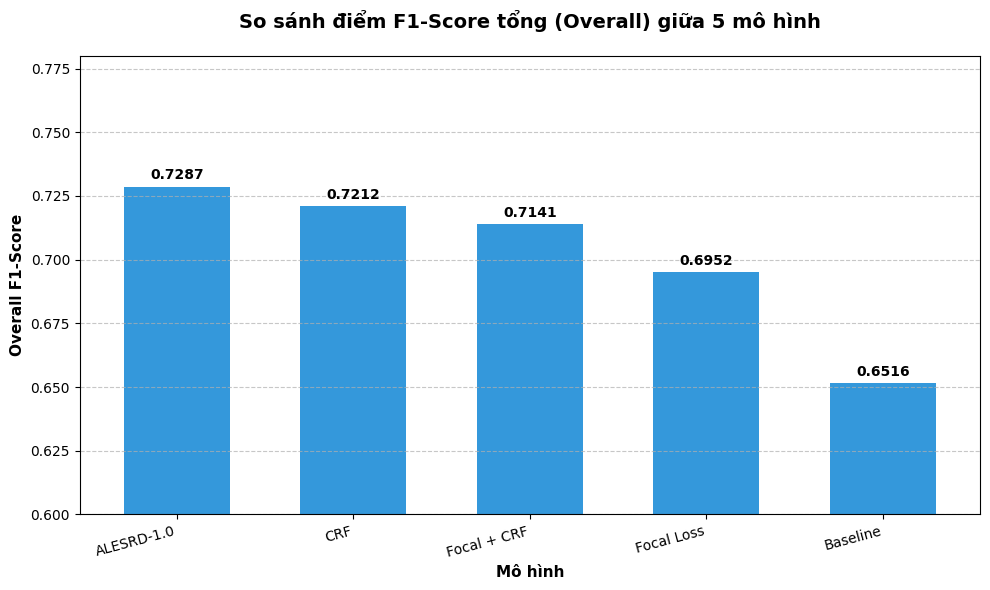

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. Tạo DataFrame từ danh sách kết quả tổng hợp
df_results = pd.DataFrame(all_metrics)

# 2. Lọc chỉ lấy cột 'Model' và 'overall_f1'
df_overall = df_results[["Model", "overall_f1"]].copy()

# 3. Sắp xếp điểm F1 từ cao đến thấp (tùy chọn để biểu đồ trực quan hơn)
df_overall = df_overall.sort_values(by="overall_f1", ascending=False)

# 4. Vẽ biểu đồ cột (Bar Chart) cho điểm tổng F1
plt.figure(figsize=(10, 6))
ax = df_overall.plot(
    kind='bar',
    x='Model',
    y='overall_f1',
    figsize=(10, 6),
    color='#3498db',
    width=0.6,
    legend=False
)

# Tiêu đề và nhãn trục
plt.title("So sánh điểm F1-Score tổng (Overall) giữa 5 mô hình", fontsize=14, fontweight='bold', pad=20)
plt.xlabel("Mô hình", fontsize=11, fontweight='bold')
plt.ylabel("Overall F1-Score", fontsize=11, fontweight='bold')

# Tinh chỉnh giao diện
plt.xticks(rotation=15, ha='right', fontsize=10)
plt.yticks(fontsize=10)
plt.ylim(0.6, 0.78)  # Cố định khoảng trục Y để thấy rõ sự chênh lệch nhỏ giữa các mô hình
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Hiển thị giá trị F1 số cụ thể ngay trên đầu mỗi cột
for container in ax.containers:
    ax.bar_label(container, fmt='%.4f', padding=3, fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()

<Figure size 1600x800 with 0 Axes>

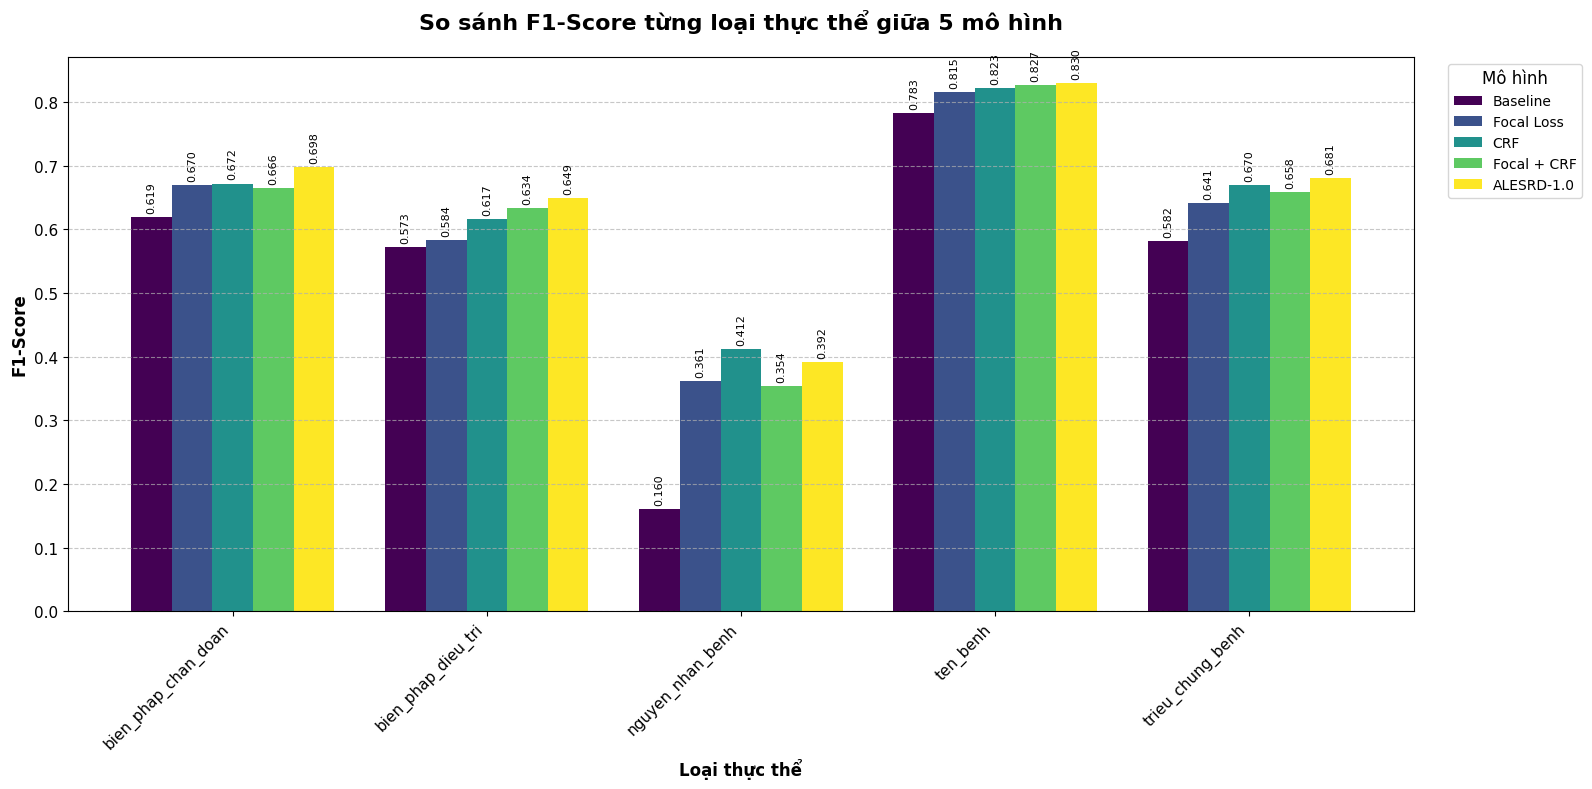

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
# 1. Tạo DataFrame từ danh sách kết quả
df_results = pd.DataFrame(all_metrics)

# 2. Lọc lấy các cột chứa điểm F1 của từng thực thể (bỏ qua điểm overall nếu muốn biểu đồ tập trung vào thực thể)
f1_columns = [col for col in df_results.columns if col.endswith("_f1") and col != "overall_f1"]
df_plot = df_results[["Model"] + f1_columns].copy()

# 3. Làm gọn tên cột (ví dụ: 'entity_B-Trieu_chung_f1' -> 'B-Trieu_chung') để trục X của biểu đồ dễ nhìn hơn
df_plot.columns = [col.replace("entity_", "").replace("_f1", "") for col in df_plot.columns]

# 4. Thiết lập cột Model làm Index và xoay bảng (Transpose)
# Việc xoay bảng giúp biểu đồ nhóm theo "Loại thực thể" ở trục X, và mỗi thực thể sẽ có 5 cột tương ứng với 5 Model
df_plot.set_index("Model", inplace=True)
df_plot = df_plot.T

# 5. Cấu hình và vẽ biểu đồ Barplot
plt.figure(figsize=(16, 8))
ax = df_plot.plot(kind='bar', figsize=(16, 8), width=0.8, colormap='viridis')

# Thêm tiêu đề và nhãn
plt.title("So sánh F1-Score từng loại thực thể giữa 5 mô hình", fontsize=16, fontweight='bold', pad=20)
plt.xlabel("Loại thực thể", fontsize=12, fontweight='bold')
plt.ylabel("F1-Score", fontsize=12, fontweight='bold')

# Căn chỉnh giao diện
plt.xticks(rotation=45, ha='right', fontsize=11)
plt.yticks(fontsize=11)
plt.legend(title="Mô hình", title_fontsize=12, fontsize=10, bbox_to_anchor=(1.02, 1), loc='upper left')
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Tuỳ chọn: Hiển thị giá trị F1 ngay trên đầu mỗi cột
for container in ax.containers:
    ax.bar_label(container, fmt='%.3f', padding=3, fontsize=8, rotation=90)

plt.tight_layout()
plt.show()

In [ ]:
# ==========================================
# 3. XUẤT KẾT QUẢ DỰ ĐOÁN ĐỂ PHÂN TÍCH LỖI (ERROR ANALYSIS)
# ==========================================
output_file = "/content/drive/MyDrive/datasetViMedNER/testset_error_analysis_Auxiliary_Loss_CRF.txt"

# Sửa lại từ pred_results thành biến predictions và labels đã có sẵn từ vòng lặp trainer.predict()
pred_ids = np.argmax(predictions, axis=2)
true_ids = labels

predicted_tags_per_sentence = []

for prediction, label in zip(pred_ids, true_ids):
    pred_sent = [id2label[int(p)] for p, l in zip(prediction, label) if l != -100]
    predicted_tags_per_sentence.append(pred_sent)

print(f"\n🔍 Đang xuất file phân tích lỗi...")
with open(output_file, "w", encoding="utf-8") as f:
    for idx, (original_sent, predicted_tags) in enumerate(zip(test_dataset.sentences, predicted_tags_per_sentence)):
        if len(original_sent) == len(predicted_tags):
            for (word, true_tag), pred_tag in zip(original_sent, predicted_tags):
                f.write(f"{word}\t{true_tag}\t{pred_tag}\n")
            f.write("\n")
        else:
            print(f"⚠️ Cảnh báo: Lệch số lượng từ ở câu {idx}, bỏ qua xuất câu này...")

print(f"✅ Đã xuất file đối chiếu thành công tại: {output_file}")


🔍 Đang xuất file phân tích lỗi...
⚠️ Cảnh báo: Lệch số lượng từ ở câu 564, bỏ qua xuất câu này...
✅ Đã xuất file đối chiếu thành công tại: /content/drive/MyDrive/datasetViMedNER/testset_error_analysis_Auxiliary_Loss_CRF.txt


In [ ]:
import numpy as np
import pandas as pd
from seqeval.metrics.sequence_labeling import get_entities
from collections import defaultdict

# 1. Lấy kết quả dự đoán từ 2 mô hình (Đảm bảo đã chạy các cell khởi tạo trainer trước đó)
print("⏳ Đang trích xuất dự đoán từ CRF và ALESRD...")
pred_crf = trainer_crf.predict(test_dataset)
pred_alesrd = trainer_ALESRD.predict(test_dataset) # Dùng mốc 1.0 đang tốt nhất

def get_bio_seqs(pred_obj):
    preds = np.argmax(pred_obj.predictions, axis=2)
    labels = pred_obj.label_ids
    true_seqs = [[id2label[l] for (p, l) in zip(prediction, label) if l != -100] for prediction, label in zip(preds, labels)]
    pred_seqs = [[id2label[p] for (p, l) in zip(prediction, label) if l != -100] for prediction, label in zip(preds, labels)]
    return true_seqs, pred_seqs

true_crf_seqs, pred_crf_seqs = get_bio_seqs(pred_crf)
_, pred_alesrd_seqs = get_bio_seqs(pred_alesrd) # True seqs là giống nhau

# 2. Hàm phân tích F1 theo Length và Type
def evaluate_advanced_buckets(true_seqs, pred_seqs, rare_hard_types=['nguyen_nhan_benh']):
    def get_len_bucket(length):
        if length <= 2: return '1. Ngắn (1-2)'
        elif length <= 4: return '2. Vừa (3-4)'
        elif length <= 7: return '3. Dài (5-7)'
        else: return '4. Siêu dài (>=8)'

    def get_type_bucket(ent_type):
        return 'Rare/Hard' if ent_type in rare_hard_types else 'Common'

    stats = defaultdict(lambda: {'TP': 0, 'FP': 0, 'FN': 0})

    for true_seq, pred_seq in zip(true_seqs, pred_seqs):
        true_ents = set(get_entities(true_seq))
        pred_ents = set(get_entities(pred_seq))

        # Đếm TP và FN từ nhãn thực tế (Ground Truth)
        for ent_type, start, end in true_ents:
            length = end - start + 1
            len_b = get_len_bucket(length)
            type_b = get_type_bucket(ent_type)
            cross_b = f"{type_b} x {len_b}"

            ent_tuple = (ent_type, start, end)
            if ent_tuple in pred_ents:
                stats[len_b]['TP'] += 1
                stats[type_b]['TP'] += 1
                stats[cross_b]['TP'] += 1
            else:
                stats[len_b]['FN'] += 1
                stats[type_b]['FN'] += 1
                stats[cross_b]['FN'] += 1

        # Đếm FP từ nhãn dự đoán
        for ent_type, start, end in pred_ents:
            if (ent_type, start, end) not in true_ents:
                length = end - start + 1
                len_b = get_len_bucket(length)
                type_b = get_type_bucket(ent_type)
                cross_b = f"{type_b} x {len_b}"

                stats[len_b]['FP'] += 1
                stats[type_b]['FP'] += 1
                stats[cross_b]['FP'] += 1

    # Tính Precision, Recall, F1
    results = {}
    for bucket, counts in stats.items():
        tp, fp, fn = counts['TP'], counts['FP'], counts['FN']
        prec = tp / (tp + fp) if tp + fp > 0 else 0
        rec = tp / (tp + fn) if tp + fn > 0 else 0
        f1 = 2 * prec * rec / (prec + rec) if prec + rec > 0 else 0
        results[bucket] = {'F1-Score': f1, 'Support': tp + fn}

    return pd.DataFrame(results).T.sort_index()

# 3. Chạy đánh giá và gộp bảng
print("📊 Đang phân tích Entity Buckets...")
df_crf = evaluate_advanced_buckets(true_crf_seqs, pred_crf_seqs)
df_alesrd = evaluate_advanced_buckets(true_crf_seqs, pred_alesrd_seqs)

# Gộp F1 của CRF và ALESRD vào cùng 1 bảng, tính Delta F1
df_final = pd.DataFrame({
    'CRF F1': df_crf['F1-Score'],
    'ALESRD F1': df_alesrd['F1-Score'],
    'Δ F1': df_alesrd['F1-Score'] - df_crf['F1-Score'],
    'Support (Số lượng)': df_crf['Support'].astype(int)
})

# Fomat hiển thị tỷ lệ phần trăm cho đẹp
df_final['CRF F1'] = (df_final['CRF F1'] * 100).map('{:.2f}%'.format)
df_final['ALESRD F1'] = (df_final['ALESRD F1'] * 100).map('{:.2f}%'.format)
df_final['Δ F1'] = (df_final['Δ F1'] * 100).map('{:+.2f}%'.format)

print("\n" + "="*80)
print("🔥 BẢNG PHÂN TÍCH ĐỘ DÀI VÀ ĐỘ KHÓ: ĐÒN KẾT LIỄU CỦA ALESRD 🔥")
print("="*80)
from IPython.display import display
display(df_final)

⏳ Đang trích xuất dự đoán từ CRF và ALESRD...


📊 Đang phân tích Entity Buckets...

🔥 BẢNG PHÂN TÍCH ĐỘ DÀI VÀ ĐỘ KHÓ: ĐÒN KẾT LIỄU CỦA ALESRD 🔥


,CRF F1,ALESRD F1,Δ F1,Support (Số lượng)
1. Ngắn (1-2),72.98%,74.51%,+1.53%,1464
2. Vừa (3-4),76.20%,76.78%,+0.58%,1491
3. Dài (5-7),70.63%,70.34%,-0.28%,611
4. Siêu dài (>=8),19.12%,26.58%,+7.45%,184
Common,74.41%,75.60%,+1.20%,3474
Common x 1. Ngắn (1-2),74.79%,76.83%,+2.04%,1374
Common x 2. Vừa (3-4),77.72%,78.63%,+0.90%,1394
Common x 3. Dài (5-7),74.14%,74.11%,-0.03%,562
Common x 4. Siêu dài (>=8),20.83%,30.30%,+9.47%,144
Rare/Hard,41.15%,39.17%,-1.99%,276


In [ ]:
import numpy as np
import pandas as pd
from seqeval.metrics.sequence_labeling import get_entities
import evaluate
from collections import defaultdict
from IPython.display import display

# Tải seqeval để phân tích tự động
seqeval = evaluate.load("seqeval")

# 1. HÀM TỰ ĐỘNG PHÂN LOẠI NHÓM RARE/HARD DỰA TRÊN DATA VÀ BASELINE CRF
def find_rare_hard_entities(true_seqs, pred_seqs, max_support=400, max_f1=0.50):
    print(f"🔍 Đang quét tự động để tìm nhóm Rare/Hard (Tiêu chí: Support < {max_support}, F1 < {max_f1})...")

    # Tính F1 và Support của từng nhãn bằng seqeval
    results = seqeval.compute(predictions=pred_seqs, references=true_seqs)

    rare_hard_list = []
    for entity_name, metrics in results.items():
        if isinstance(metrics, dict): # Bỏ qua các dòng overall
            support = metrics['number']
            f1_score = metrics['f1']

            if support < max_support and f1_score < max_f1:
                rare_hard_list.append(entity_name)
                print(f"   👉 [CHỌN]: '{entity_name}' (Support: {support}, F1: {f1_score:.4f}) -> Đạt tiêu chí Rare/Hard")
            else:
                print(f"   -  [BỎ QUA]: '{entity_name}' (Support: {support}, F1: {f1_score:.4f}) -> Xếp vào Common/Easy")

    return rare_hard_list

# Chạy tìm kiếm tự động trên kết quả của CRF
dynamic_rare_hard_types = find_rare_hard_entities(true_crf_seqs, pred_crf_seqs)

# 2. HÀM PHÂN TÍCH ĐỘ DÀI VÀ ĐỘ KHÓ (Nhận danh sách nhãn tự động)
def evaluate_advanced_buckets_dynamic(true_seqs, pred_seqs, rare_hard_types):
    def get_len_bucket(length):
        if length <= 2: return '1. Ngắn (1-2)'
        elif length <= 4: return '2. Vừa (3-4)'
        elif length <= 7: return '3. Dài (5-7)'
        else: return '4. Siêu dài (>=8)'

    def get_type_bucket(ent_type):
        return 'Rare/Hard' if ent_type in rare_hard_types else 'Common'

    stats = defaultdict(lambda: {'TP': 0, 'FP': 0, 'FN': 0})

    for true_seq, pred_seq in zip(true_seqs, pred_seqs):
        true_ents = set(get_entities(true_seq))
        pred_ents = set(get_entities(pred_seq))

        # Đếm TP và FN từ nhãn thực tế
        for ent_type, start, end in true_ents:
            length = end - start + 1
            len_b = get_len_bucket(length)
            type_b = get_type_bucket(ent_type)
            cross_b = f"{type_b} x {len_b}"

            ent_tuple = (ent_type, start, end)
            if ent_tuple in pred_ents:
                stats[len_b]['TP'] += 1
                stats[type_b]['TP'] += 1
                stats[cross_b]['TP'] += 1
            else:
                stats[len_b]['FN'] += 1
                stats[type_b]['FN'] += 1
                stats[cross_b]['FN'] += 1

        # Đếm FP từ nhãn dự đoán
        for ent_type, start, end in pred_ents:
            if (ent_type, start, end) not in true_ents:
                length = end - start + 1
                len_b = get_len_bucket(length)
                type_b = get_type_bucket(ent_type)
                cross_b = f"{type_b} x {len_b}"

                stats[len_b]['FP'] += 1
                stats[type_b]['FP'] += 1
                stats[cross_b]['FP'] += 1

    # Tính Precision, Recall, F1
    results = {}
    for bucket, counts in stats.items():
        tp, fp, fn = counts['TP'], counts['FP'], counts['FN']
        prec = tp / (tp + fp) if tp + fp > 0 else 0
        rec = tp / (tp + fn) if tp + fn > 0 else 0
        f1 = 2 * prec * rec / (prec + rec) if prec + rec > 0 else 0
        results[bucket] = {'F1-Score': f1, 'Support': tp + fn}

    return pd.DataFrame(results).T.sort_index()

# =====================================================================
# BƯỚC 1: XÁC ĐỊNH NHÓM RARE/HARD DỰA TRÊN TẬP DEV (KHÔNG ĐỤNG TEST SET)
# =====================================================================
print("⏳ Đang chạy CRF Baseline trên tập DEV để xác định nhóm Rare/Hard...")
dev_dataset_filepath = '/content/drive/MyDrive/datasetViMedNER/PreprocessedData/dev_dataset.pkl'
dev_dataset = load_dataset(dev_dataset_filepath)
pred_crf_dev = trainer_crf.predict(dev_dataset)
true_dev_seqs, pred_dev_crf_seqs = get_bio_seqs(pred_crf_dev)

# Chốt danh sách cố định từ tập DEV (Tiêu chí: Support < 400, F1 < 0.5)
fixed_rare_hard_types = find_rare_hard_entities(true_dev_seqs, pred_dev_crf_seqs, max_support=400, max_f1=0.50)

print(f"\n🔒 ĐÃ CHỐT DANH SÁCH RARE/HARD TỪ TẬP DEV: {fixed_rare_hard_types}")
print("Mô hình sẽ sử dụng danh sách cố định này để đánh giá độc lập trên tập TEST.\n")

# =====================================================================
# BƯỚC 2: PHÂN TÍCH HIỆU NĂNG TRÊN TẬP TEST BẰNG DANH SÁCH CỐ ĐỊNH
# =====================================================================
print("📊 Đang tiến hành phân tích Entity Buckets trên tập TEST...")
df_crf = evaluate_advanced_buckets_dynamic(true_crf_seqs, pred_crf_seqs, fixed_rare_hard_types)
df_alesrd = evaluate_advanced_buckets_dynamic(true_crf_seqs, pred_alesrd_seqs, fixed_rare_hard_types)

df_final = pd.DataFrame({
    'CRF F1': df_crf['F1-Score'],
    'ALESRD F1': df_alesrd['F1-Score'],
    'Δ F1': df_alesrd['F1-Score'] - df_crf['F1-Score'],
    'Support (Số lượng)': df_crf['Support'].astype(int)
})

# Format hiển thị
df_final['CRF F1'] = (df_final['CRF F1'] * 100).map('{:.2f}%'.format)
df_final['ALESRD F1'] = (df_final['ALESRD F1'] * 100).map('{:.2f}%'.format)
df_final['Δ F1'] = (df_final['Δ F1'] * 100).map('{:+.2f}%'.format)

print("="*85)
print("🔥 BẢNG PHÂN TÍCH ĐỘ DÀI VÀ ĐỘ KHÓ (CHỐT TỪ DEV, ĐÁNH GIÁ TRÊN TEST) 🔥")
print("="*85)
display(df_final)

🔍 Đang quét tự động để tìm nhóm Rare/Hard (Tiêu chí: Support < 400, F1 < 0.5)...
   -  [BỎ QUA]: 'bien_phap_chan_doan' (Support: 308, F1: 0.6720) -> Xếp vào Common/Easy
   -  [BỎ QUA]: 'bien_phap_dieu_tri' (Support: 632, F1: 0.6166) -> Xếp vào Common/Easy
   👉 [CHỌN]: 'nguyen_nhan_benh' (Support: 276, F1: 0.4115) -> Đạt tiêu chí Rare/Hard
   -  [BỎ QUA]: 'ten_benh' (Support: 1822, F1: 0.8227) -> Xếp vào Common/Easy
   -  [BỎ QUA]: 'trieu_chung_benh' (Support: 712, F1: 0.6700) -> Xếp vào Common/Easy
⏳ Đang chạy CRF Baseline trên tập DEV để xác định nhóm Rare/Hard...


🔍 Đang quét tự động để tìm nhóm Rare/Hard (Tiêu chí: Support < 400, F1 < 0.5)...
   -  [BỎ QUA]: 'bien_phap_chan_doan' (Support: 271, F1: 0.6323) -> Xếp vào Common/Easy
   -  [BỎ QUA]: 'bien_phap_dieu_tri' (Support: 653, F1: 0.6238) -> Xếp vào Common/Easy
   👉 [CHỌN]: 'nguyen_nhan_benh' (Support: 259, F1: 0.3234) -> Đạt tiêu chí Rare/Hard
   -  [BỎ QUA]: 'ten_benh' (Support: 1795, F1: 0.8282) -> Xếp vào Common/Easy
   -  [BỎ QUA]: 'trieu_chung_benh' (Support: 747, F1: 0.6442) -> Xếp vào Common/Easy

🔒 ĐÃ CHỐT DANH SÁCH RARE/HARD TỪ TẬP DEV: ['nguyen_nhan_benh']
Mô hình sẽ sử dụng danh sách cố định này để đánh giá độc lập trên tập TEST.

📊 Đang tiến hành phân tích Entity Buckets trên tập TEST...
🔥 BẢNG PHÂN TÍCH ĐỘ DÀI VÀ ĐỘ KHÓ (CHỐT TỪ DEV, ĐÁNH GIÁ TRÊN TEST) 🔥


,CRF F1,ALESRD F1,Δ F1,Support (Số lượng)
1. Ngắn (1-2),72.98%,74.51%,+1.53%,1464
2. Vừa (3-4),76.20%,76.78%,+0.58%,1491
3. Dài (5-7),70.63%,70.34%,-0.28%,611
4. Siêu dài (>=8),19.12%,26.58%,+7.45%,184
Common,74.41%,75.60%,+1.20%,3474
Common x 1. Ngắn (1-2),74.79%,76.83%,+2.04%,1374
Common x 2. Vừa (3-4),77.72%,78.63%,+0.90%,1394
Common x 3. Dài (5-7),74.14%,74.11%,-0.03%,562
Common x 4. Siêu dài (>=8),20.83%,30.30%,+9.47%,144
Rare/Hard,41.15%,39.17%,-1.99%,276


In [ ]:
from seqeval.metrics.sequence_labeling import get_entities

# 1. Cấu hình độ dài tối thiểu muốn khảo sát (Nên để 5 hoặc 6 để dễ tìm ví dụ hay)
MIN_LEN = 5

print(f"🔍 ĐANG TÌM CASE STUDY: CRF CẮT LỖI - ALESRD ĐOÁN CHUẨN (Độ dài >= {MIN_LEN})\n")
print("="*90)

found_cases = 0
limit_examples = 15 # Số lượng ví dụ muốn lấy để làm Slide

for i, (true_seq, pred_crf, pred_alesrd) in enumerate(zip(true_crf_seqs, pred_crf_seqs, pred_alesrd_seqs)):
    # Lấy danh sách từ vựng gốc của câu từ test_dataset
    tokens = [word for word, tag in test_dataset.sentences[i]]

    # Đảm bảo độ dài khớp nhau (bỏ qua các câu bị cắt cụt do max_length)
    if len(tokens) != len(true_seq): continue

    true_ents = get_entities(true_seq)
    pred_crf_ents = get_entities(pred_crf)
    pred_alesrd_ents = get_entities(pred_alesrd)

    for ent_type, start, end in true_ents:
        length = end - start + 1

        if length >= MIN_LEN:
            # Điều kiện 1: ALESRD bắt trọn vẹn ranh giới và nhãn
            alesrd_correct = (ent_type, start, end) in pred_alesrd_ents

            # Điều kiện 2: CRF không bắt được cụm nguyên vẹn này
            crf_wrong = (ent_type, start, end) not in pred_crf_ents

            if alesrd_correct and crf_wrong:
                found_cases += 1

                print(f"🟢 VÍ DỤ {found_cases} (Câu số {i}) - Thực thể: [{ent_type}] - Dài: {length} tokens")

                # Text thực tế
                true_text = " ".join(tokens[start:end+1])
                print(f"   🎯 GROUND TRUTH : {true_text}")
                print(f"   🏆 ALESRD (Đúng) : {true_text}")

                # Khôi phục xem CRF đã "băm nát" cụm này ra sao
                crf_mistake_pieces = []
                for c_type, c_start, c_end in pred_crf_ents:
                    # Kiểm tra xem có đè (overlap) lên cụm gốc không
                    if max(start, c_start) <= min(end, c_end):
                        piece_text = " ".join(tokens[max(start, c_start):min(end, c_end)+1])
                        crf_mistake_pieces.append(f"[{c_type}] {piece_text}")

                if not crf_mistake_pieces:
                    crf_mistake = "[O] (Mô hình bỏ sót hoàn toàn)"
                else:
                    crf_mistake = " + ".join(crf_mistake_pieces) + " ⚠️ (Bị cắt vụn / Sai nhãn)"

                print(f"   ❌ CRF (Sai)     : {crf_mistake}")
                print("-" * 90)

                if found_cases >= limit_examples:
                    break
    if found_cases >= limit_examples:
        break

if found_cases == 0:
    print(f"Không tìm thấy ví dụ nào có độ dài >= {MIN_LEN} thỏa mãn điều kiện.")
else:
    print("\n✅ Xong! Hãy chọn 2-3 ví dụ đẹp nhất đưa lên Slide/Luận văn.")


🔍 ĐANG TÌM CASE STUDY: CRF CẮT LỖI - ALESRD ĐOÁN CHUẨN (Độ dài >= 5)

🟢 VÍ DỤ 1 (Câu số 5) - Thực thể: [bien_phap_dieu_tri] - Dài: 17 tokens
   🎯 GROUND TRUTH : điều chỉnh độ tương phản và độ sáng trên màn hình đến một mức độ thoải mái
   🏆 ALESRD (Đúng) : điều chỉnh độ tương phản và độ sáng trên màn hình đến một mức độ thoải mái
   ❌ CRF (Sai)     : [bien_phap_dieu_tri] điều chỉnh độ tương phản và độ sáng trên màn hình ⚠️ (Bị cắt vụn / Sai nhãn)
------------------------------------------------------------------------------------------
🟢 VÍ DỤ 2 (Câu số 10) - Thực thể: [trieu_chung_benh] - Dài: 9 tokens
   🎯 GROUND TRUTH : bàn chân và các ngón chân to bất thường
   🏆 ALESRD (Đúng) : bàn chân và các ngón chân to bất thường
   ❌ CRF (Sai)     : [trieu_chung_benh] bàn chân + [trieu_chung_benh] to ⚠️ (Bị cắt vụn / Sai nhãn)
------------------------------------------------------------------------------------------
🟢 VÍ DỤ 3 (Câu số 11) - Thực thể: [bien_phap_dieu_tri] - Dài: 14 tokens
   🎯 